# Análisis y Visualización Avanzada

## Contexto empresarial

AndesRetail S.A.C. es una empresa ficticia de retail omnicanal que opera 25 tiendas en cinco ciudades del Perú: Lima, Arequipa, Trujillo, Cusco y Piura.

Durante los últimos dos años, la gerencia ha incrementado la inversión en marketing y ha impulsado el canal digital. Las ventas han crecido, pero la dirección comercial no tiene claridad sobre qué indicadores están realmente relacionados con el crecimiento.

Algunos gerentes consideran que la inversión en marketing explica el incremento de ventas. Otros sostienen que son la cantidad de clientes, los pedidos, la satisfacción y los tiempos de entrega.

Además, el área de analítica ha detectado que varios indicadores parecen comportarse de forma muy similar, por lo que podría existir multicolinealidad o redundancia entre algunos KPI.

La empresa solicita al equipo de analistas realizar un estudio exploratorio y presentar los principales hallazgos a la Gerencia General.

## Objetivo

Su responsabilidad será analizar los indicadores comerciales de la empresa utilizando Python, Pandas, Matplotlib y Seaborn.

**¿Qué variables están más relacionadas con las ventas y qué indicadores podrían estar proporcionando información redundante?**

## Data

Archivo: `andes_retail_kpis.csv`

| Campo                 | Descripción                       |
| --------------------- | --------------------------------- |
| `periodo`             | Mes analizado                     |
| `tienda_id`           | Código de la tienda               |
| `ciudad`              | Ciudad                            |
| `canal_principal`     | Tienda, Mixto u Online            |
| `ventas_mensuales`    | Ventas mensuales en soles         |
| `clientes`            | Clientes atendidos                |
| `pedidos`             | Número de pedidos                 |
| `visitas_web`         | Visitas al sitio web              |
| `inversion_marketing` | Inversión mensual en marketing    |
| `descuento_promedio`  | Porcentaje promedio de descuento  |
| `ticket_promedio`     | Importe promedio de compra        |
| `satisfaccion`        | Satisfacción del cliente de 1 a 5 |
| `reclamos`            | Reclamos recibidos                |
| `tiempo_entrega_dias` | Tiempo promedio de entrega        |
| `costo_logistico`     | Costo logístico mensual           |
| `tasa_conversion`     | Porcentaje de conversión          |


Intalar libreria `scipy`

```python
python -m pip install scipy
```

In [38]:
!python -m pip install scipy

Defaulting to user installation because normal site-packages is not writeable


In [39]:
## 1. Cargando librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy  

In [37]:
## 2. Cargando el dataset
df = pd.read_csv("./data/andes_retail_kpis.csv")
df.head()


,periodo,tienda_id,ciudad,canal_principal,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
0,2024-01-01,T01,Cusco,Mixto,138521.42,1839,1498,31880,42347.91,8.13,92.64,4.40,10,3.89,13463.16,4.34
1,2024-02-01,T01,Cusco,Mixto,131347.71,1837,1452,34031,44353.16,8.72,86.74,4.35,8,4.05,9183.76,3.87
2,2024-03-01,T01,Cusco,Mixto,125321.00,1986,1510,31197,41095.47,11.07,80.51,3.96,19,4.51,12801.02,5.09
3,2024-04-01,T01,Cusco,Mixto,152746.30,1992,1589,29873,39305.27,7.52,92.62,4.62,9,3.00,14712.22,5.01
4,2024-05-01,T01,Cusco,Mixto,144961.39,1996,1666,34747,44860.34,5.67,88.29,4.52,8,4.00,10625.89,4.98


In [40]:
## Tamaño del dataset
df.shape

(600, 16)

In [41]:
## Información del dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   periodo              600 non-null    str    
 1   tienda_id            600 non-null    str    
 2   ciudad               600 non-null    str    
 3   canal_principal      600 non-null    str    
 4   ventas_mensuales     600 non-null    float64
 5   clientes             600 non-null    int64  
 6   pedidos              600 non-null    int64  
 7   visitas_web          600 non-null    int64  
 8   inversion_marketing  600 non-null    float64
 9   descuento_promedio   600 non-null    float64
 10  ticket_promedio      600 non-null    float64
 11  satisfaccion         600 non-null    float64
 12  reclamos             600 non-null    int64  
 13  tiempo_entrega_dias  600 non-null    float64
 14  costo_logistico      600 non-null    float64
 15  tasa_conversion      600 non-null    float64
dtypes

In [42]:
## Estadísticas descriptivas
df.describe()

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,148634.481433,2044.645000,1618.696667,23726.491667,29938.424417,9.331517,89.265383,4.486017,9.596667,3.297767,15168.257717,7.539083
std,37409.335565,471.225524,377.558497,6952.528599,10091.271297,3.177806,6.456810,0.300639,6.091730,0.663311,4782.945476,3.089775
min,65410.050000,977.000000,756.000000,7444.000000,7038.420000,0.420000,66.810000,3.520000,0.000000,1.200000,5000.000000,2.540000
25%,120627.070000,1671.750000,1330.500000,18199.750000,21695.655000,7.147500,84.987500,4.287500,5.000000,2.847500,12121.430000,5.387500
50%,143774.340000,2001.000000,1583.000000,24011.000000,29758.150000,9.155000,89.260000,4.490000,9.000000,3.310000,14869.925000,6.805000
75%,174562.512500,2394.500000,1894.000000,29039.000000,38223.010000,11.272500,93.730000,4.710000,13.000000,3.780000,18592.932500,9.007500
max,298523.330000,3576.000000,2893.000000,41151.000000,55016.650000,19.080000,107.710000,5.000000,38.000000,5.210000,31963.530000,19.950000


In [43]:
## Columnas categoricas
categorical_columns = df.select_dtypes(include=['object']).columns
categorical_columns

C:\Users\Marlon\AppData\Local\Temp\ipykernel_34804\1965734562.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


Index(['periodo', 'tienda_id', 'ciudad', 'canal_principal'], dtype='str')

In [44]:
## Convertir la columna periodo a datatime
df['periodo'] = pd.to_datetime(df['periodo'], format='%Y-%m-%d')

In [46]:
df.head()

,periodo,tienda_id,ciudad,canal_principal,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
0,2024-01-01,T01,Cusco,Mixto,138521.42,1839,1498,31880,42347.91,8.13,92.64,4.40,10,3.89,13463.16,4.34
1,2024-02-01,T01,Cusco,Mixto,131347.71,1837,1452,34031,44353.16,8.72,86.74,4.35,8,4.05,9183.76,3.87
2,2024-03-01,T01,Cusco,Mixto,125321.00,1986,1510,31197,41095.47,11.07,80.51,3.96,19,4.51,12801.02,5.09
3,2024-04-01,T01,Cusco,Mixto,152746.30,1992,1589,29873,39305.27,7.52,92.62,4.62,9,3.00,14712.22,5.01
4,2024-05-01,T01,Cusco,Mixto,144961.39,1996,1666,34747,44860.34,5.67,88.29,4.52,8,4.00,10625.89,4.98


In [47]:
## Generando matriz de Pearson
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
correlation_pearson = df[columnas_numericas].corr(method='pearson')
correlation_pearson

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,1.000000,0.914000,0.923230,0.070693,0.043745,-0.053125,0.335581,0.259211,-0.246456,-0.327403,0.678805,0.430080
clientes,0.914000,1.000000,0.985866,0.028562,0.006747,0.043196,0.065633,0.221341,-0.205315,-0.292693,0.638108,0.498961
pedidos,0.923230,0.985866,1.000000,0.018634,-0.002230,0.035958,0.055888,0.211576,-0.196306,-0.286737,0.639506,0.511274
visitas_web,0.070693,0.028562,0.018634,1.000000,0.939387,0.037759,0.014072,0.038341,-0.031287,-0.032497,0.065364,-0.777140
inversion_marketing,0.043745,0.006747,-0.002230,0.939387,1.000000,0.042808,0.009265,0.052677,-0.045510,-0.046878,0.069399,-0.736959
descuento_promedio,-0.053125,0.043196,0.035958,0.037759,0.042808,1.000000,-0.267997,0.037621,-0.021395,-0.027310,-0.015826,0.016729
ticket_promedio,0.335581,0.065633,0.055888,0.014072,0.009265,-0.267997,1.000000,0.266388,-0.272955,-0.235409,0.219586,0.026596
satisfaccion,0.259211,0.221341,0.211576,0.038341,0.052677,0.037621,0.266388,1.000000,-0.913073,-0.777005,0.089506,0.083045
reclamos,-0.246456,-0.205315,-0.196306,-0.031287,-0.045510,-0.021395,-0.272955,-0.913073,1.000000,0.751012,-0.077628,-0.089521
tiempo_entrega_dias,-0.327403,-0.292693,-0.286737,-0.032497,-0.046878,-0.027310,-0.235409,-0.777005,0.751012,1.000000,-0.128477,-0.141431


In [48]:
## Funcion para clasificar la correlación (alta > 0.7, moderada 0.3-0.7, baja < 0.3)
def clasificar_correlacion(valor):
    if abs(valor) > 0.7:
        return 'alta'
    elif abs(valor) > 0.3:
        return 'moderada'
    else:
        return 'baja'

In [49]:
## Recorriendo la matriz de correlación y clasificando los valores
matriz_pearson = correlation_pearson.apply(lambda columna: columna.map(clasificar_correlacion))
matriz_pearson

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,alta,alta,alta,baja,baja,baja,moderada,baja,baja,moderada,moderada,moderada
clientes,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
pedidos,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
visitas_web,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,alta
inversion_marketing,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,alta
descuento_promedio,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja,baja
ticket_promedio,moderada,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja
satisfaccion,baja,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja
reclamos,baja,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja
tiempo_entrega_dias,moderada,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja


In [50]:
## Generando matriz de spearman
correlation_spearman = df[columnas_numericas].corr(method='spearman')
correlation_spearman

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,1.000000,0.911615,0.922171,0.046008,0.020659,-0.055131,0.318754,0.242539,-0.229525,-0.306602,0.676596,0.494808
clientes,0.911615,1.000000,0.984259,-0.000066,-0.017901,0.030789,0.074179,0.215251,-0.208660,-0.279565,0.623916,0.566581
pedidos,0.922171,0.984259,1.000000,-0.010668,-0.026780,0.026033,0.060089,0.200670,-0.192777,-0.270408,0.625273,0.583233
visitas_web,0.046008,-0.000066,-0.010668,1.000000,0.945116,0.030543,0.007174,0.030135,-0.044021,-0.033007,0.048158,-0.786313
inversion_marketing,0.020659,-0.017901,-0.026780,0.945116,1.000000,0.035779,0.003133,0.048593,-0.056303,-0.049873,0.057320,-0.750050
descuento_promedio,-0.055131,0.030789,0.026033,0.030543,0.035779,1.000000,-0.266655,0.028592,-0.013781,-0.011099,-0.019819,0.005255
ticket_promedio,0.318754,0.074179,0.060089,0.007174,0.003133,-0.266655,1.000000,0.249451,-0.233300,-0.234344,0.229329,0.028025
satisfaccion,0.242539,0.215251,0.200670,0.030135,0.048593,0.028592,0.249451,1.000000,-0.912494,-0.764281,0.116090,0.101058
reclamos,-0.229525,-0.208660,-0.192777,-0.044021,-0.056303,-0.013781,-0.233300,-0.912494,1.000000,0.758924,-0.110723,-0.077130
tiempo_entrega_dias,-0.306602,-0.279565,-0.270408,-0.033007,-0.049873,-0.011099,-0.234344,-0.764281,0.758924,1.000000,-0.153169,-0.140758


In [51]:
## Recorriendo la matriz de correlación y clasificando los valores
matriz_spearman = correlation_spearman.apply(lambda columna: columna.map(clasificar_correlacion))
matriz_spearman

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,alta,alta,alta,baja,baja,baja,moderada,baja,baja,moderada,moderada,moderada
clientes,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
pedidos,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
visitas_web,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,alta
inversion_marketing,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,alta
descuento_promedio,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja,baja
ticket_promedio,moderada,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja
satisfaccion,baja,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja
reclamos,baja,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja
tiempo_entrega_dias,moderada,baja,baja,baja,baja,baja,baja,alta,alta,alta,baja,baja


In [52]:
## Generando matriz de kendall
correlation_kendall = df[columnas_numericas].corr(method='kendall')
correlation_kendall

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,1.000000,0.738293,0.757045,0.032327,0.014502,-0.035426,0.215083,0.164074,-0.157377,-0.208162,0.485055,0.340971
clientes,0.738293,1.000000,0.893023,0.003195,-0.010270,0.020116,0.049284,0.144486,-0.141637,-0.190719,0.442884,0.395043
pedidos,0.757045,0.893023,1.000000,-0.004019,-0.016171,0.016730,0.040243,0.135114,-0.131395,-0.183602,0.443844,0.408948
visitas_web,0.032327,0.003195,-0.004019,1.000000,0.792319,0.020968,0.004664,0.021059,-0.030583,-0.021566,0.031525,-0.585761
inversion_marketing,0.014502,-0.010270,-0.016171,0.792319,1.000000,0.024291,0.002744,0.031901,-0.038257,-0.033182,0.038119,-0.553425
descuento_promedio,-0.035426,0.020116,0.016730,0.020968,0.024291,1.000000,-0.179018,0.019243,-0.009702,-0.007906,-0.013019,0.003515
ticket_promedio,0.215083,0.049284,0.040243,0.004664,0.002744,-0.179018,1.000000,0.170628,-0.162294,-0.158017,0.151360,0.018351
satisfaccion,0.164074,0.144486,0.135114,0.021059,0.031901,0.019243,0.170628,1.000000,-0.765050,-0.574048,0.076588,0.066033
reclamos,-0.157377,-0.141637,-0.131395,-0.030583,-0.038257,-0.009702,-0.162294,-0.765050,1.000000,0.575463,-0.074840,-0.052707
tiempo_entrega_dias,-0.208162,-0.190719,-0.183602,-0.021566,-0.033182,-0.007906,-0.158017,-0.574048,0.575463,1.000000,-0.102881,-0.094197


In [53]:
## Recorriendo la matriz de correlación y clasificando los valores
matriz_kendall = correlation_kendall.apply(lambda columna: columna.map(clasificar_correlacion))
matriz_kendall

,ventas_mensuales,clientes,pedidos,visitas_web,inversion_marketing,descuento_promedio,ticket_promedio,satisfaccion,reclamos,tiempo_entrega_dias,costo_logistico,tasa_conversion
ventas_mensuales,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
clientes,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
pedidos,alta,alta,alta,baja,baja,baja,baja,baja,baja,baja,moderada,moderada
visitas_web,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,moderada
inversion_marketing,baja,baja,baja,alta,alta,baja,baja,baja,baja,baja,baja,moderada
descuento_promedio,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja,baja
ticket_promedio,baja,baja,baja,baja,baja,baja,alta,baja,baja,baja,baja,baja
satisfaccion,baja,baja,baja,baja,baja,baja,baja,alta,alta,moderada,baja,baja
reclamos,baja,baja,baja,baja,baja,baja,baja,alta,alta,moderada,baja,baja
tiempo_entrega_dias,baja,baja,baja,baja,baja,baja,baja,moderada,moderada,alta,baja,baja


In [55]:
## Tabla de correlaciones por pares de variables
pares = {
    'Clientes / Pedidos': ('clientes', 'pedidos'),
    'Marketing / Visitas': ('inversion_marketing', 'visitas_web'),
    'Satisfacción / Reclamos': ('satisfaccion', 'reclamos'),
}

def interpretar_correlacion(v1, v2, valor):
    if abs(valor) > 0.7:
        fuerza = 'fuerte'
    elif abs(valor) > 0.3:
        fuerza = 'moderada'
    else:
        fuerza = 'débil'

    if valor > 0:
        return f'Relación {fuerza} y positiva: a mayor {v1}, mayor {v2}.'
    else:
        return f'Relación {fuerza} y negativa: a mayor {v1}, menor {v2}.'

tabla_correlaciones = pd.DataFrame({
    'variables': list(pares.keys()),
    'Pearson': [matriz_pearson.loc[v1, v2] for v1, v2 in pares.values()],
    'Spearman': [matriz_spearman.loc[v1, v2] for v1, v2 in pares.values()],
    'Kendall': [matriz_kendall.loc[v1, v2] for v1, v2 in pares.values()],
})

tabla_correlaciones['interpretacion'] = [
    interpretar_correlacion(v1, v2, correlation_pearson.loc[v1, v2])
    for v1, v2 in pares.values()
]

tabla_correlaciones

,variables,Pearson,Spearman,Kendall,interpretacion
0,Clientes / Pedidos,alta,alta,alta,"Relación fuerte y positiva: a mayor clientes, ..."
1,Marketing / Visitas,alta,alta,alta,Relación fuerte y positiva: a mayor inversion_...
2,Satisfacción / Reclamos,alta,alta,alta,Relación fuerte y negativa: a mayor satisfacci...


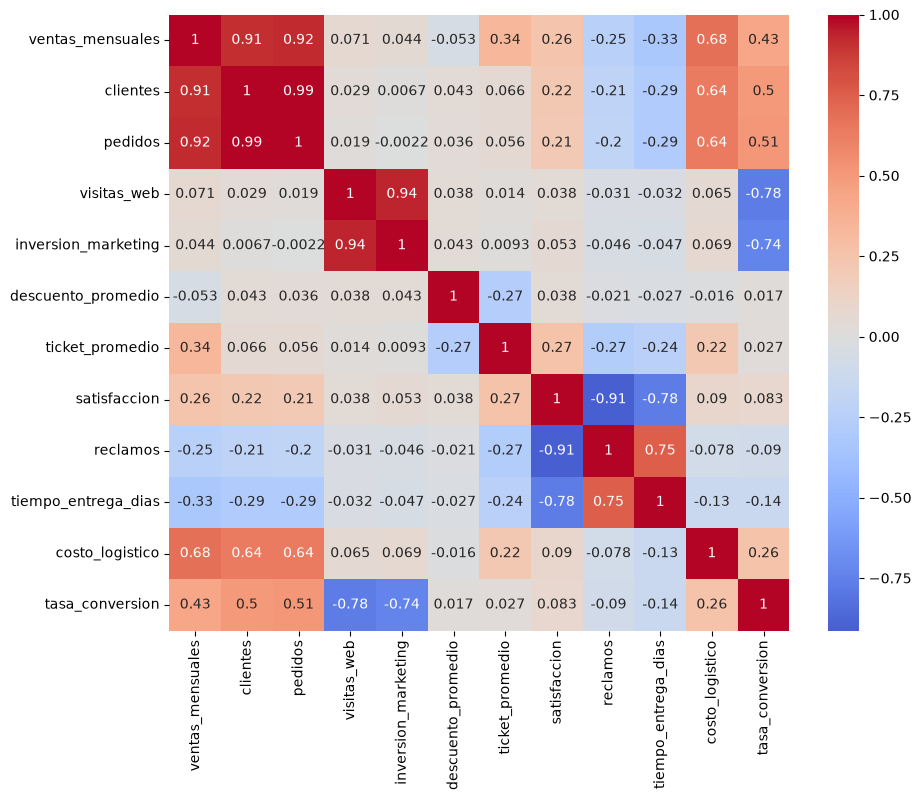

In [56]:
## Mostrar el grafico headmap de correlación de Pearson
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_pearson, annot=True, cmap='coolwarm', center=0)
plt.show()

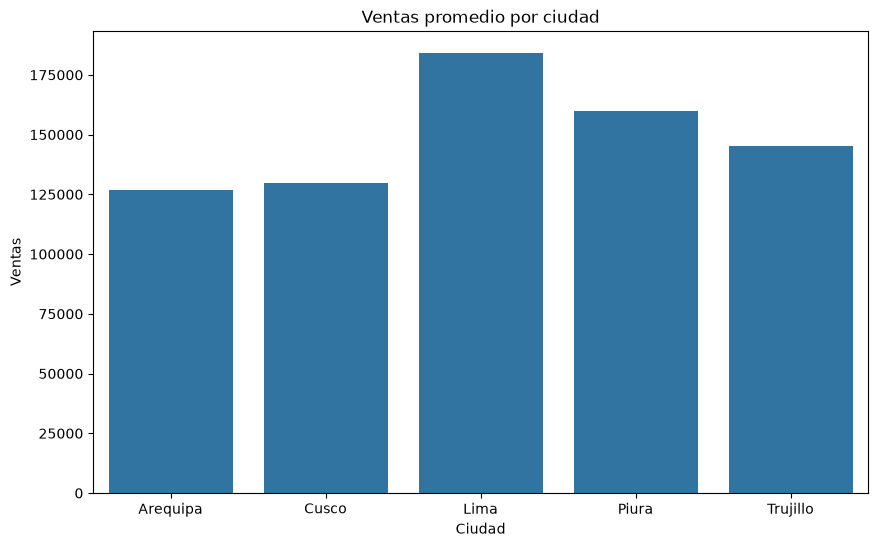

In [58]:
## Graficar las Ventas promedio por ciudad
plt.figure(figsize=(10, 6))
sns.barplot(x='ciudad', y='ventas_mensuales', data=df.groupby('ciudad')['ventas_mensuales'].mean().reset_index())
plt.xlabel('Ciudad')
plt.ylabel('Ventas')
plt.title('Ventas promedio por ciudad')
plt.show()

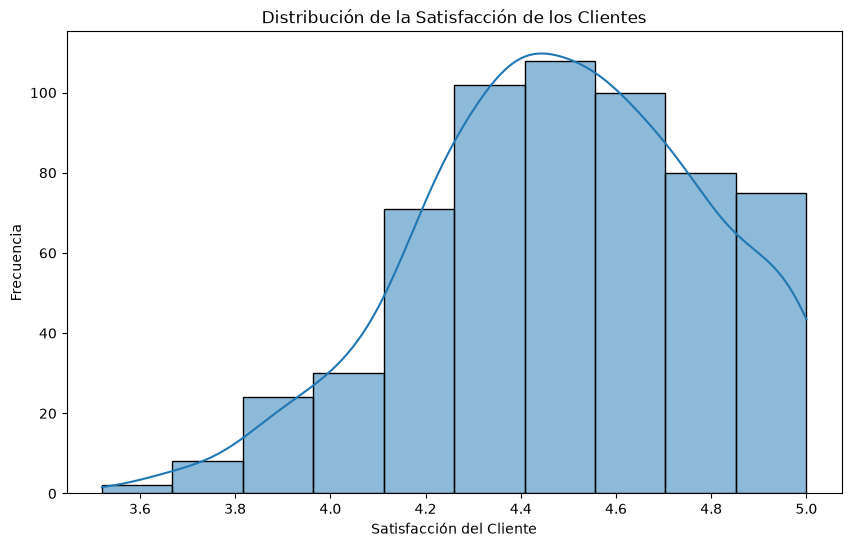

In [60]:
## Distribución de la satisfacción de los clientes (histograma)
plt.figure(figsize=(10, 6))
sns.histplot(df['satisfaccion'], bins=10, kde=True)
plt.xlabel('Satisfacción del Cliente')
plt.ylabel('Frecuencia')
plt.title('Distribución de la Satisfacción de los Clientes')
plt.show()

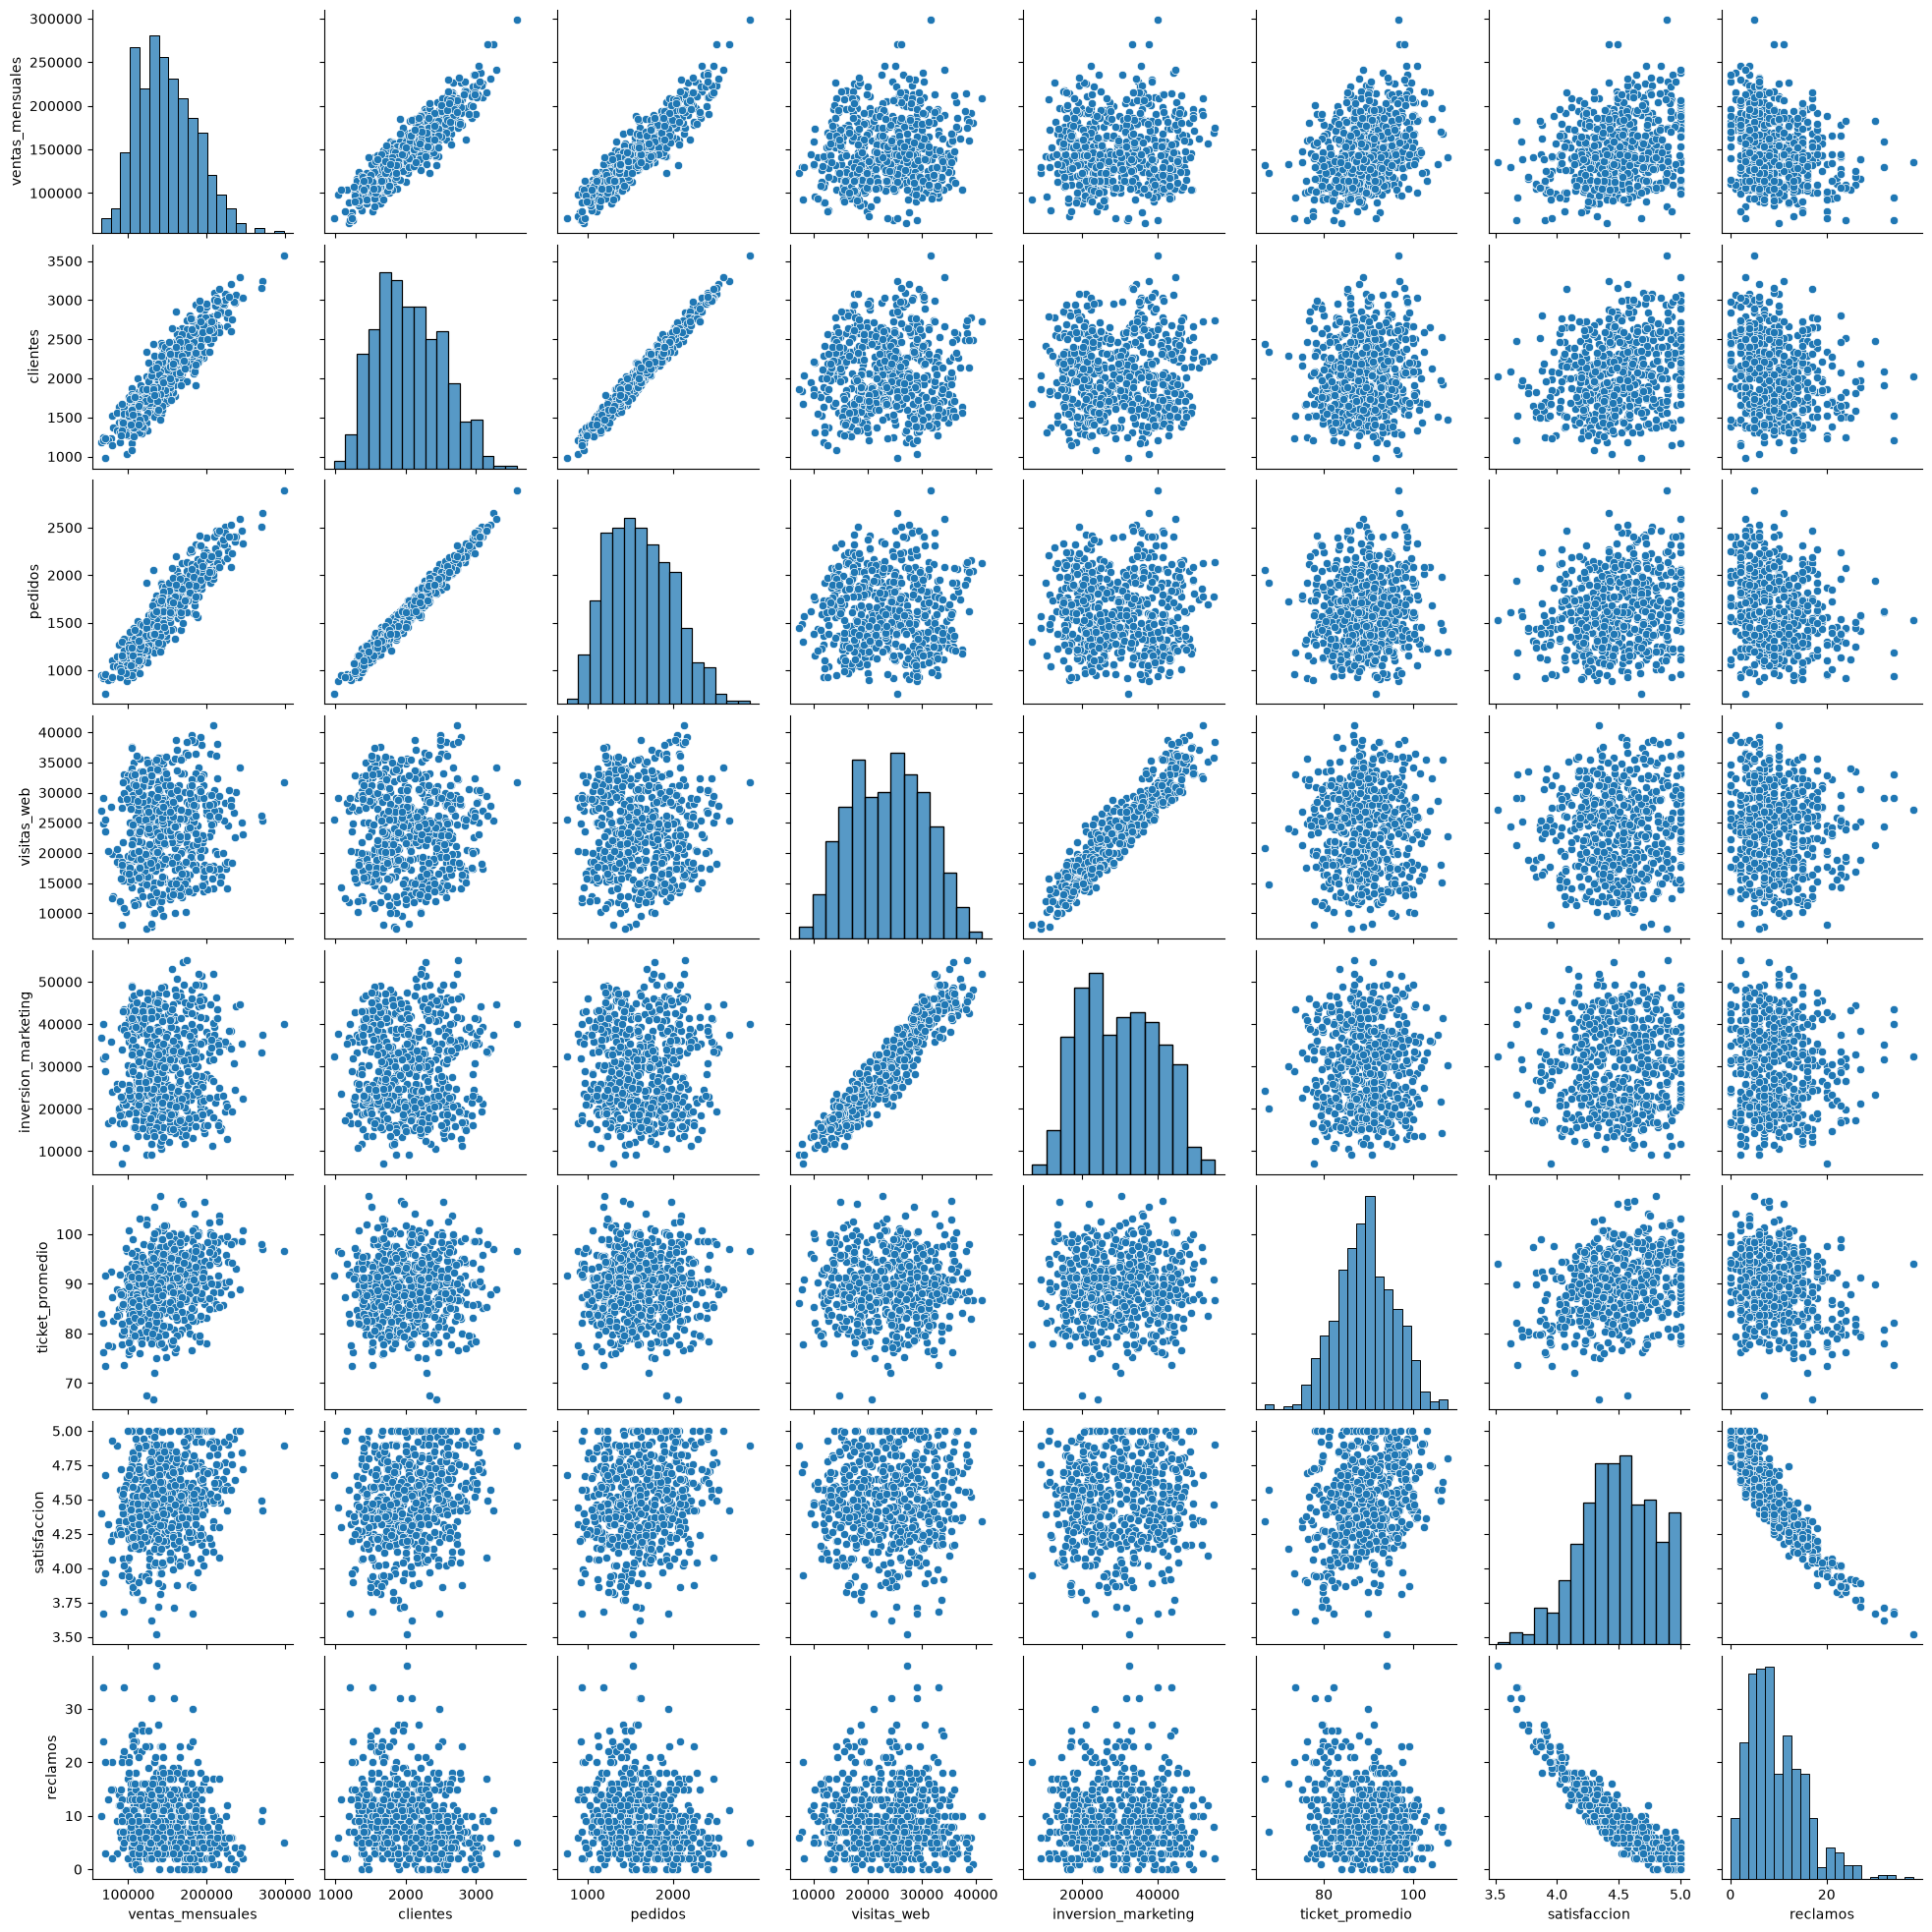

In [62]:
# Graficar la correlacion de las variables (usando pairplot de seaborn):
sns.pairplot(df[['ventas_mensuales', 'clientes', 'pedidos', 'visitas_web', 'inversion_marketing', 'ticket_promedio', 'satisfaccion', 'reclamos']])
plt.show()

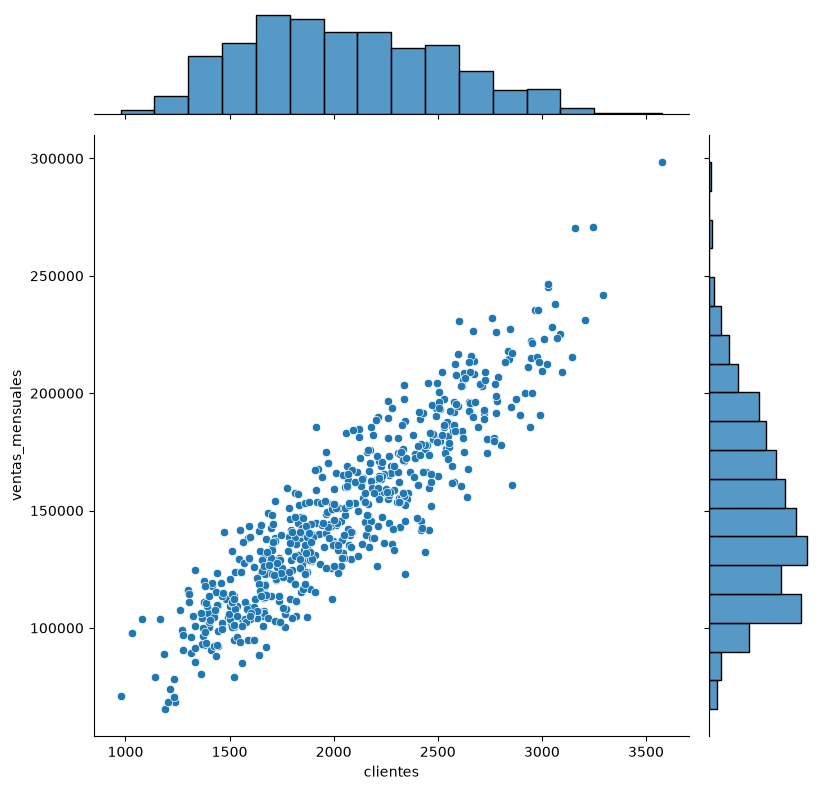

In [63]:
# Graficar la relacion de clientes con ventas mensuales (usar jointplot de seaborn):
sns.jointplot(x='clientes', y='ventas_mensuales', data=df, kind='scatter', height=8)
plt.show()

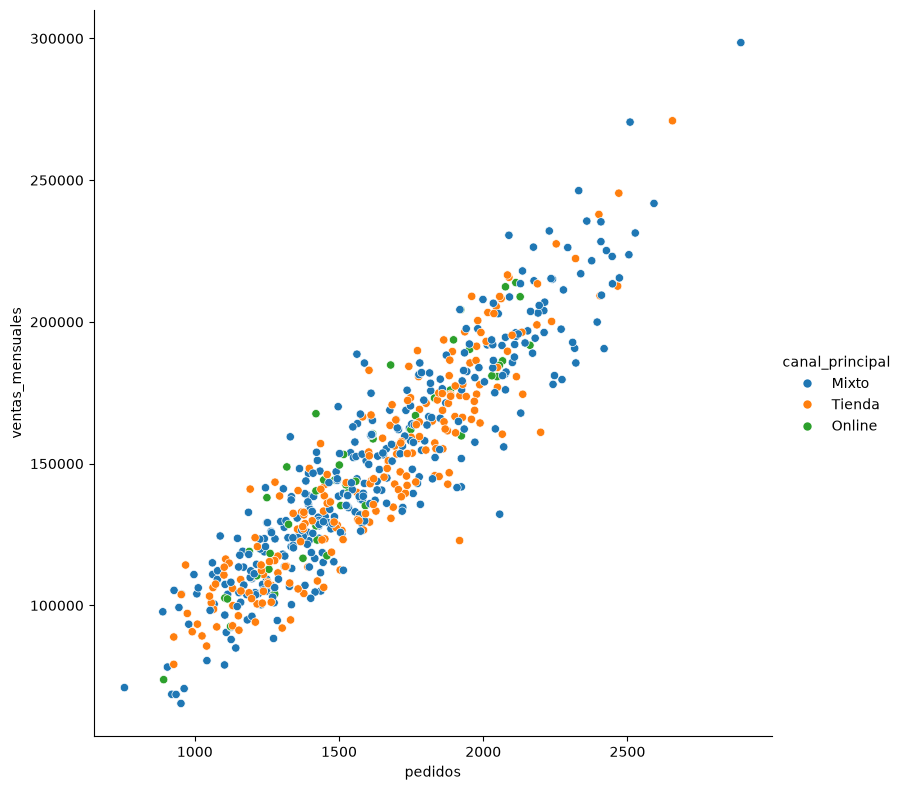

In [66]:
# Graficar la relacion de las variables pedidos y ventas_mensuales, diferenciando los puntos por canal principal (usar relplot de seaborn):
sns.relplot(x='pedidos', y='ventas_mensuales', hue='canal_principal', data=df, kind='scatter', height=8)
plt.show()